In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [7]:
# ── Plot Style ────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

# ── Load Merged Data ──────────────────────────────────────
df = pd.read_csv('../data/processed/merged_data.csv')
print(f"Loaded: {df.shape[0]:,} rows | {df.shape[1]:,} columns")

Loaded: 590,540 rows | 434 columns


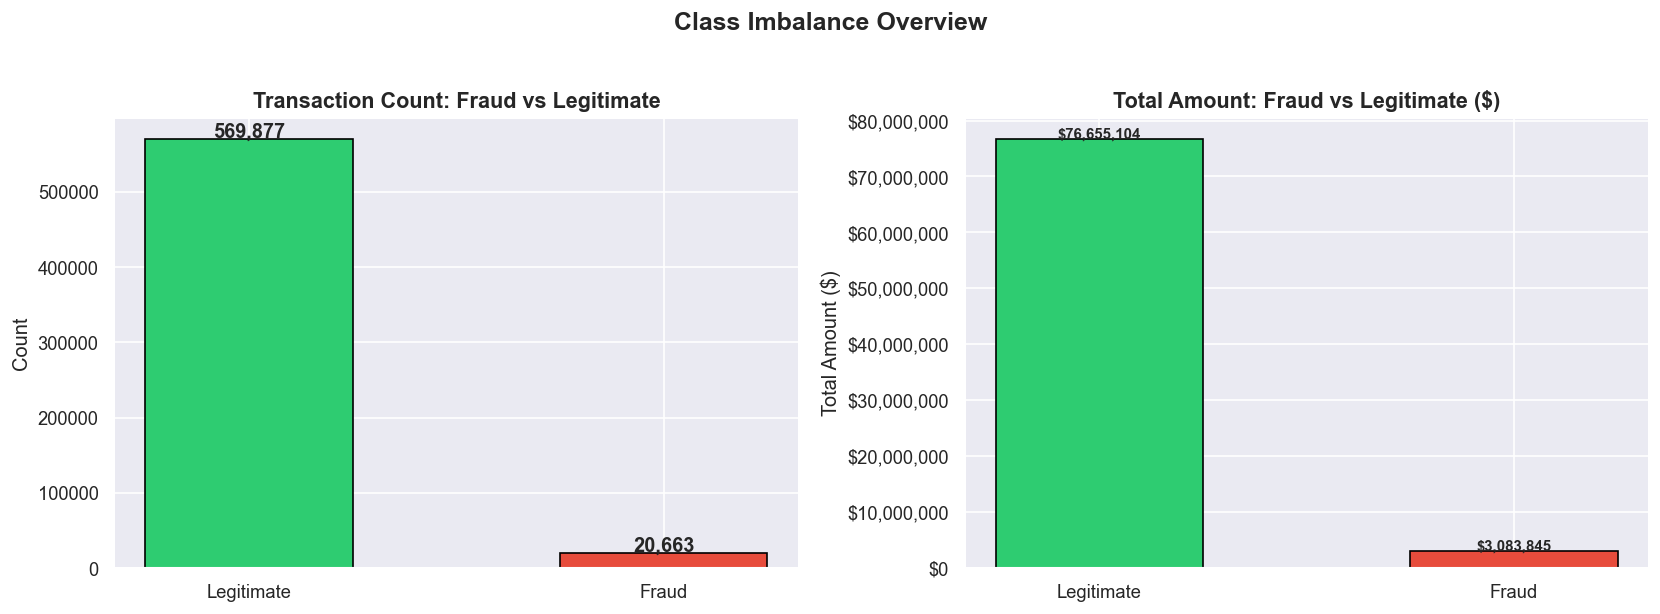


[BUSINESS INSIGHT]
Fraud is only 3.50% of transactions but accounts for 3.87% of total amount.
Fraudsters transact in slightly higher amounts on average.
A naive model predicting all-legitimate gets 96.5% accuracy — completely useless.


In [8]:
# ============================================================
# SECTION 1: CLASS IMBALANCE
# Business Question: How severe is the fraud imbalance?
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
fraud_counts = df['isFraud'].value_counts()
axes[0].bar(['Legitimate', 'Fraud'],fraud_counts.values,color=['#2ecc71', '#e74c3c'],edgecolor='black', width=0.5)
axes[0].set_title('Transaction Count: Fraud vs Legitimate', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold')

# Amount comparison
fraud_amt    = df[df['isFraud'] == 1]['TransactionAmt'].sum()
legit_amt    = df[df['isFraud'] == 0]['TransactionAmt'].sum()
axes[1].bar(['Legitimate', 'Fraud'],[legit_amt, fraud_amt],color=['#2ecc71', '#e74c3c'],
            edgecolor='black', width=0.5
)
axes[1].set_title('Total Amount: Fraud vs Legitimate ($)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Total Amount ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, v in enumerate([legit_amt, fraud_amt]):
    axes[1].text(i, v + 100000, f'${v:,.0f}', ha='center', fontweight='bold', fontsize=9)
    
plt.suptitle('Class Imbalance Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/eda_01_class_imbalance.png', bbox_inches='tight')
plt.show()

print("\n[BUSINESS INSIGHT]")
print(f"Fraud is only 3.50% of transactions but accounts for 3.87% of total amount.")
print(f"Fraudsters transact in slightly higher amounts on average.")
print(f"A naive model predicting all-legitimate gets 96.5% accuracy — completely useless.")

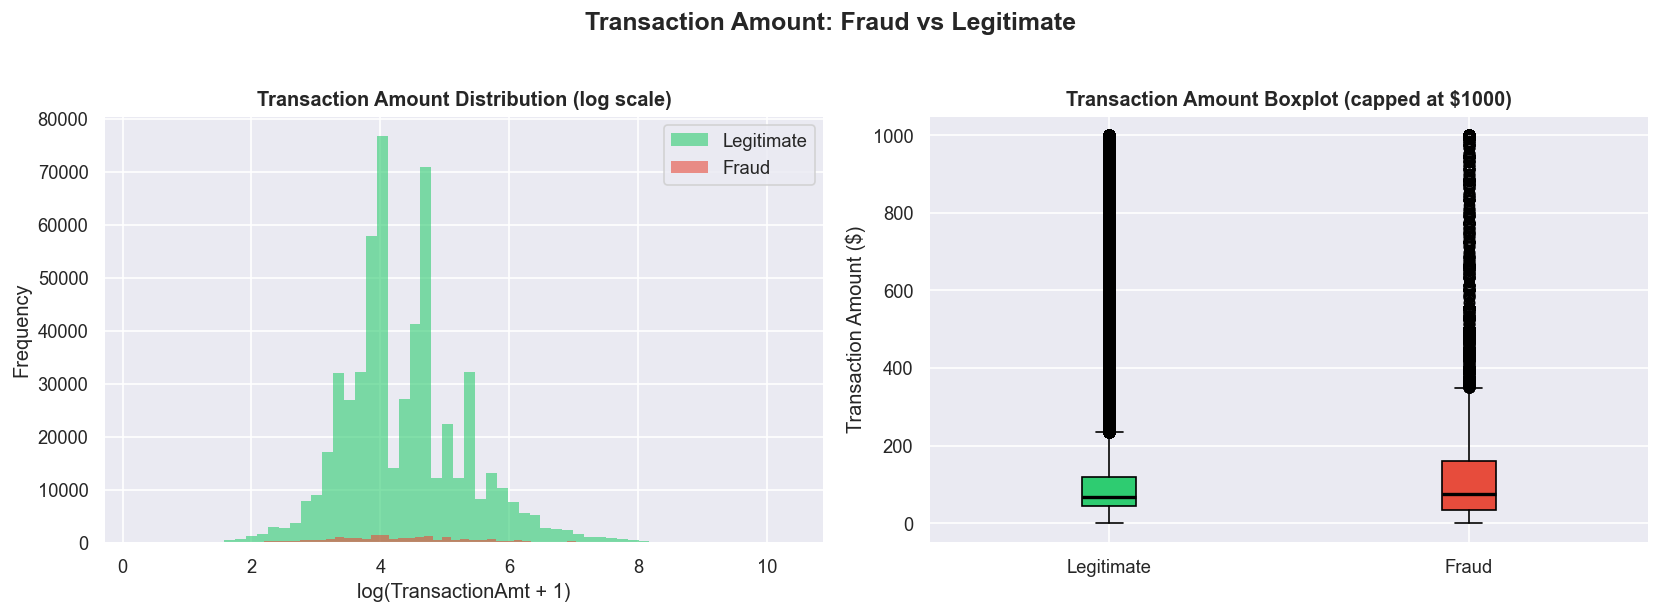


[TRANSACTION AMOUNT STATS BY FRAUD LABEL]
            count    mean     std   min    25%   50%    75%       max
isFraud                                                              
0        569877.0  134.51  239.40  0.25  43.97  68.5  120.0  31937.39
1         20663.0  149.24  232.21  0.29  35.04  75.0  161.0   5191.00


In [10]:
# ============================================================
# SECTION 2: TRANSACTION AMOUNT ANALYSIS
# Business Question: Do fraudulent transactions differ in amount?
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution (log scale for readability)
for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
    subset = df[df['isFraud'] == label]['TransactionAmt']
    axes[0].hist(np.log1p(subset),bins=60,alpha=0.6,color=color,label='Legitimate' if label == 0 else 'Fraud',
                 edgecolor='none')

axes[0].set_title('Transaction Amount Distribution (log scale)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('log(TransactionAmt + 1)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Boxplot comparison
fraud_box_data = [
    df[df['isFraud'] == 0]['TransactionAmt'].clip(upper=1000),
    df[df['isFraud'] == 1]['TransactionAmt'].clip(upper=1000)
]
bp = axes[1].boxplot(fraud_box_data,labels=['Legitimate', 'Fraud'],patch_artist=True,
                     medianprops=dict(color='black', linewidth=2)
)

bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
axes[1].set_title('Transaction Amount Boxplot (capped at $1000)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Transaction Amount ($)')

plt.suptitle('Transaction Amount: Fraud vs Legitimate', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/eda_02_transaction_amount.png', bbox_inches='tight')
plt.show()

# Stats
print("\n[TRANSACTION AMOUNT STATS BY FRAUD LABEL]")
print(df.groupby('isFraud')['TransactionAmt'].describe().round(2).to_string())

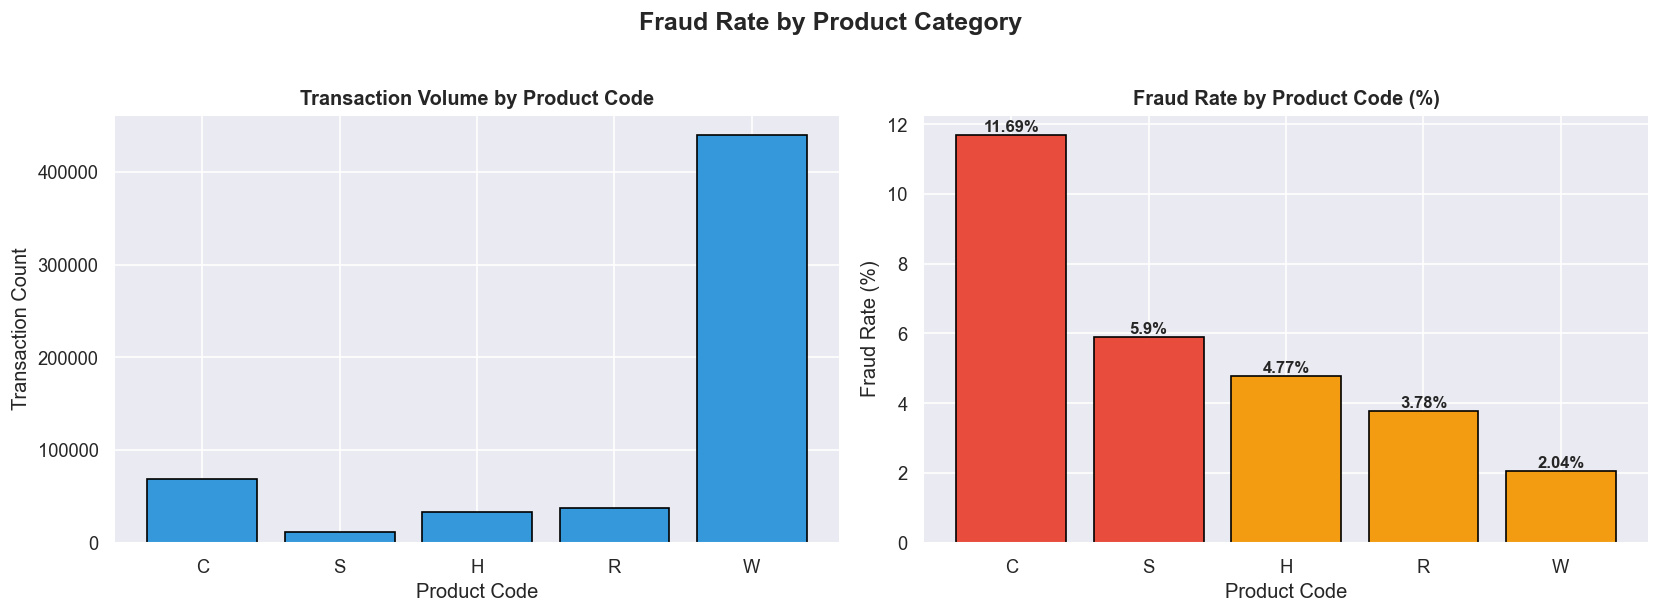


[PRODUCT CODE FRAUD BREAKDOWN]
ProductCD  total  fraud  fraud_rate
        C  68519   8008       11.69
        S  11628    686        5.90
        H  33024   1574        4.77
        R  37699   1426        3.78
        W 439670   8969        2.04


In [12]:
# ============================================================
# SECTION 3: PRODUCT CODE ANALYSIS
# Business Question: Which product categories have highest fraud?
# ============================================================

product_fraud = df.groupby('ProductCD').agg(total=('isFraud', 'count'),fraud=('isFraud', 'sum')).reset_index()
product_fraud['fraud_rate'] = (product_fraud['fraud'] / product_fraud['total'] * 100).round(2)
product_fraud = product_fraud.sort_values('fraud_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Transaction volume
axes[0].bar(product_fraud['ProductCD'],product_fraud['total'],color='#3498db', edgecolor='black')
axes[0].set_title('Transaction Volume by Product Code', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Product Code')
axes[0].set_ylabel('Transaction Count')

# Fraud rate
bars = axes[1].bar(
    product_fraud['ProductCD'],product_fraud['fraud_rate'],
    color=['#e74c3c' if r > 5 else '#f39c12' if r > 2 else '#2ecc71'
           for r in product_fraud['fraud_rate']],
    edgecolor='black'
)

axes[1].set_title('Fraud Rate by Product Code (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Product Code')
axes[1].set_ylabel('Fraud Rate (%)')
for bar, rate in zip(bars, product_fraud['fraud_rate']):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f'{rate}%', ha='center', fontweight='bold', fontsize=10
    )

plt.suptitle('Fraud Rate by Product Category', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/eda_03_product_fraud.png', bbox_inches='tight')
plt.show()

print("\n[PRODUCT CODE FRAUD BREAKDOWN]")
print(product_fraud.to_string(index=False))

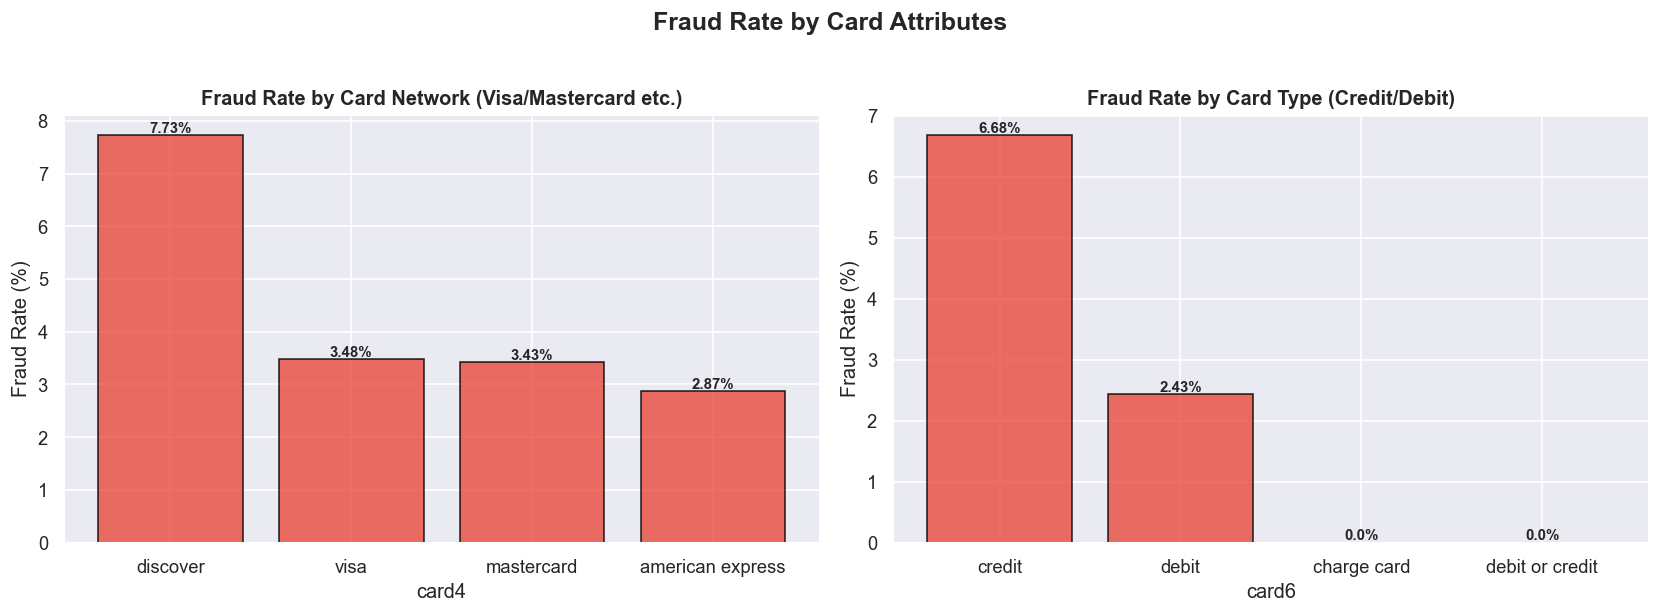

In [13]:
# ============================================================
# SECTION 4: CARD TYPE ANALYSIS
# Business Question: Which card networks / types attract more fraud?
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(
    axes,
    ['card4', 'card6'],
    ['Card Network (Visa/Mastercard etc.)', 'Card Type (Credit/Debit)']
):
    card_fraud = df.groupby(col)['isFraud'].mean().mul(100).round(2).sort_values(ascending=False)
    
    bars = ax.bar(card_fraud.index.astype(str),card_fraud.values,
        color='#e74c3c', edgecolor='black', alpha=0.8
    )
    ax.set_title(f'Fraud Rate by {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Fraud Rate (%)')
    for bar, val in zip(bars, card_fraud.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f'{val}%', ha='center', fontweight='bold', fontsize=9
        )

plt.suptitle('Fraud Rate by Card Attributes', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/eda_04_card_fraud.png', bbox_inches='tight')
plt.show()

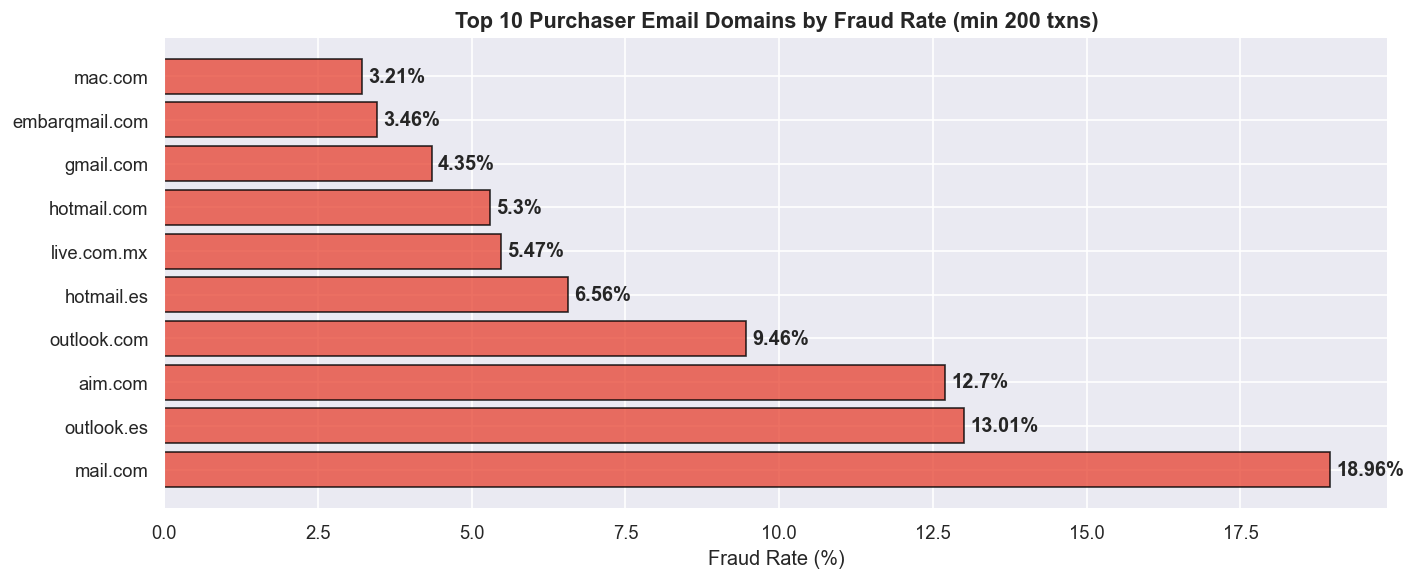

In [14]:
# ============================================================
# SECTION 5: EMAIL DOMAIN ANALYSIS
# Business Question: Are certain email domains associated with fraud?
# ============================================================

# Purchaser email
top_email_fraud = (
    df.groupby('P_emaildomain')['isFraud']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'fraud_rate', 'count': 'total'})
)
top_email_fraud = top_email_fraud[top_email_fraud['total'] > 200]
top_email_fraud['fraud_rate'] = (top_email_fraud['fraud_rate'] * 100).round(2)
top_email_fraud = top_email_fraud.sort_values('fraud_rate', ascending=False).head(10)

plt.figure(figsize=(12, 5))
bars = plt.barh(
    top_email_fraud['P_emaildomain'],
    top_email_fraud['fraud_rate'],
    color='#e74c3c', edgecolor='black', alpha=0.8
)
plt.xlabel('Fraud Rate (%)')
plt.title('Top 10 Purchaser Email Domains by Fraud Rate (min 200 txns)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, top_email_fraud['fraud_rate']):
    plt.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
             f'{val}%', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/eda_05_email_fraud.png', bbox_inches='tight')
plt.show()

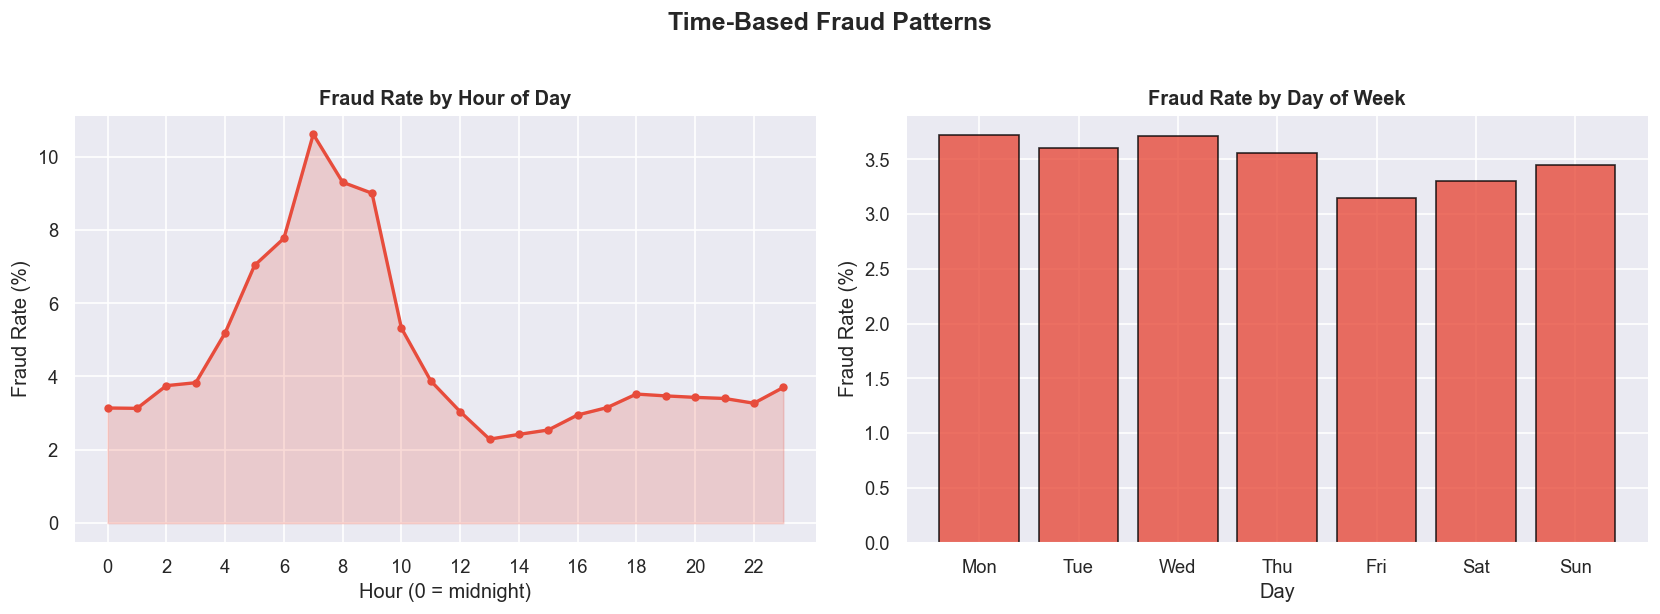

In [15]:
# ============================================================
# SECTION 6: TIME-BASED FRAUD PATTERN
# Business Question: When does fraud peak — by hour and day?
# ============================================================

# TransactionDT is seconds from a reference point
# Convert to hour of day and day of week
df['hour'] = (df['TransactionDT'] // 3600) % 24
df['day']  = (df['TransactionDT'] // (3600 * 24)) % 7

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fraud rate by hour
hour_fraud = df.groupby('hour')['isFraud'].mean().mul(100).round(2)
axes[0].plot(hour_fraud.index, hour_fraud.values, color='#e74c3c', linewidth=2, marker='o', markersize=4)
axes[0].fill_between(hour_fraud.index, hour_fraud.values, alpha=0.2, color='#e74c3c')
axes[0].set_title('Fraud Rate by Hour of Day', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hour (0 = midnight)')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_xticks(range(0, 24, 2))

# Fraud rate by day
day_fraud = df.groupby('day')['isFraud'].mean().mul(100).round(2)
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(day_labels[:len(day_fraud)],day_fraud.values,color='#e74c3c', edgecolor='black', alpha=0.8)
axes[1].set_title('Fraud Rate by Day of Week', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Fraud Rate (%)')

plt.suptitle('Time-Based Fraud Patterns', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/eda_06_time_fraud.png', bbox_inches='tight')
plt.show()

In [16]:
# ============================================================
# SECTION 7: MISSING VALUE STRATEGY DECISION
# Business Question: Which columns are safe to keep vs drop?
# ============================================================

missing_pct = df.isnull().mean().mul(100).round(2)

# Categorize columns by missing %
drop_cols    = missing_pct[missing_pct > 70].index.tolist()
impute_cols  = missing_pct[(missing_pct > 0) & (missing_pct <= 70)].index.tolist()
clean_cols   = missing_pct[missing_pct == 0].index.tolist()

print("\n========== MISSING VALUE STRATEGY ==========")
print(f"Columns to DROP   (>70% missing) : {len(drop_cols)}")
print(f"Columns to IMPUTE (1-70% missing): {len(impute_cols)}")
print(f"Columns CLEAN     (0% missing)   : {len(clean_cols)}")
print(f"Total columns                    : {df.shape[1]}")
print("=============================================")

# Save strategy summary
strategy_df = pd.DataFrame({
    'column': missing_pct.index,
    'missing_pct': missing_pct.values,
    'strategy': ['DROP' if p > 70 else 'IMPUTE' if p > 0 else 'KEEP'
                 for p in missing_pct.values]
})
strategy_df.to_csv('../data/processed/missing_value_strategy.csv', index=False)
print("\nMissing value strategy saved.")


========== MISSING VALUE STRATEGY ==========
Columns to DROP   (>70% missing) : 208
Columns to IMPUTE (1-70% missing): 174
Columns CLEAN     (0% missing)   : 54
Total columns                    : 436

Missing value strategy saved.


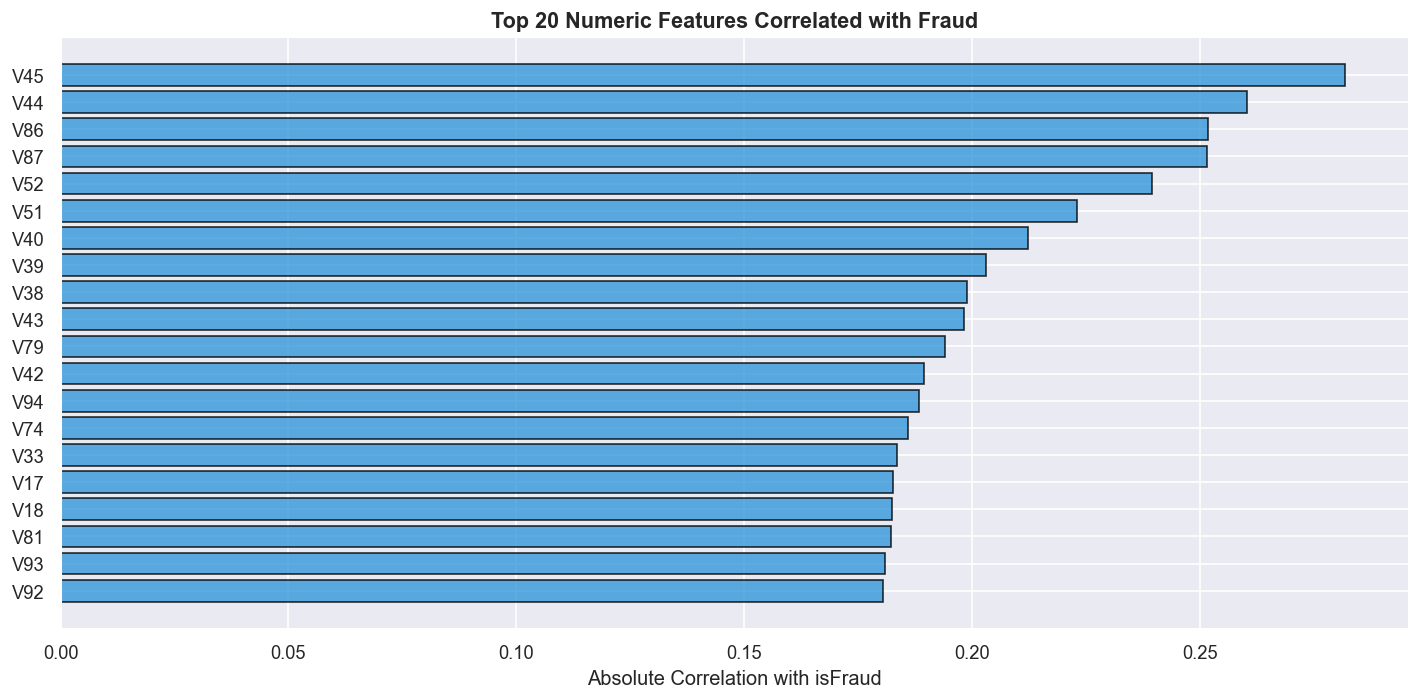


[TOP 10 FEATURES CORRELATED WITH FRAUD]
V45    0.281832
V44    0.260376
V86    0.251828
V87    0.251737
V52    0.239469
V51    0.223191
V40    0.212442
V39    0.203097
V38    0.199005
V43    0.198274


In [17]:
# ============================================================
# SECTION 8: CORRELATION WITH FRAUD (Numeric Features)
# Business Question: Which numeric features correlate most with fraud?
# ============================================================

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['TransactionID', 'isFraud', 'TransactionDT']]

# Keep only columns with <50% missing for correlation
usable_cols = [c for c in numeric_cols if df[c].isnull().mean() < 0.5]

corr_with_fraud = (
    df[usable_cols + ['isFraud']]
    .corr()['isFraud']
    .drop('isFraud')
    .abs()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12, 6))
bars = plt.barh(
    corr_with_fraud.index[::-1],
    corr_with_fraud.values[::-1],
    color='#3498db', edgecolor='black', alpha=0.8
)
plt.xlabel('Absolute Correlation with isFraud')
plt.title('Top 20 Numeric Features Correlated with Fraud', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/eda_07_correlation.png', bbox_inches='tight')
plt.show()

print("\n[TOP 10 FEATURES CORRELATED WITH FRAUD]")
print(corr_with_fraud.head(10).to_string())

In [18]:
# Save EDA-processed data with time features
df.to_csv('../data/processed/eda_data.csv', index=False)
print("EDA data with time features saved.")

EDA data with time features saved.
